# Clustering NBA Players by Playing Style

**Season:** 2023–24 Regular Season  
**Clusters:** 6 player archetypes  
**Filter:** ≥30 games, ≥15 minutes/game

---

## Workflow
1. **Data Pull** — NBA per-game stats via `nba_api`
2. **Preprocessing** — Filter, clean, standardize
3. **EDA** — Distributions, correlations, top players
4. **Clustering** — K-Means (K=6) with elbow + silhouette tuning
5. **Dimensionality Reduction** — PCA & UMAP
6. **Visualization** — 13 figures across multiple formats

In [1]:
import warnings; warnings.filterwarnings('ignore')
import time, os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import plotly.express as px, plotly.graph_objects as go
from nba_api.stats.endpoints import leaguedashplayerstats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
try:
    import umap.umap_ as umap_module
    UMAP_AVAILABLE = True
except:
    UMAP_AVAILABLE = False

plt.rcParams['figure.figsize'] = (14, 6); plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)
os.makedirs('../data', exist_ok=True)
print('✓ Imports OK' + (' | UMAP available' if UMAP_AVAILABLE else ' | UMAP will use PCA fallback'))

✓ Imports OK | UMAP available


## 1. Data Pull (2023–24 Season)

In [2]:
from nba_api.stats.endpoints import playerindex

print('Fetching NBA per-game stats...')
time.sleep(1)
endpoint = leaguedashplayerstats.LeagueDashPlayerStats(
    season='2023-24', per_mode_detailed='PerGame', season_type_all_star='Regular Season')
df_raw = endpoint.get_data_frames()[0]
print(f'Raw: {len(df_raw)} players, {df_raw.shape[1]} columns')

# Fetch player position and height data
print('Fetching player positions...')
time.sleep(1)
try:
    pi = playerindex.PlayerIndex(season='2023-24')
    df_pos = pi.get_data_frames()[0][['PERSON_ID', 'POSITION', 'HEIGHT']].rename(columns={'PERSON_ID': 'PLAYER_ID'})
    df_raw = df_raw.merge(df_pos, on='PLAYER_ID', how='left')
    n_matched = df_raw['POSITION'].notna().sum()
    print(f'Positions joined: {n_matched}/{len(df_raw)} players')
    print(df_raw['POSITION'].value_counts().to_string())
except Exception as e:
    print(f'Position fetch failed ({e}), defaulting all to Forward')
    df_raw['POSITION'] = 'F'
    df_raw['HEIGHT'] = '6-6'

Fetching NBA per-game stats...


Raw: 572 players, 67 columns
Fetching player positions...


Positions joined: 139/572 players
POSITION
G      55
F      46
C      14
G-F    10
F-C     6
F-G     5
C-F     3


## 2. Preprocessing (≥30 GP, ≥15 MIN/G)

In [3]:
RAW_COLS = ['PTS', 'AST', 'REB', 'STL', 'BLK', 'TOV', 'FG_PCT', 'FG3_PCT', 'FT_PCT',
            'MIN', 'PLUS_MINUS', 'FGA', 'FG3A', 'FTA', 'OREB', 'DREB']

# Apply thresholds; keep POSITION and HEIGHT through the filter
df = df_raw[(df_raw['GP'] >= 30) & (df_raw['MIN'] >= 15)].copy()
df = df[['PLAYER_NAME', 'TEAM_ABBREVIATION', 'GP', 'POSITION', 'HEIGHT'] + RAW_COLS].copy()
df.dropna(subset=RAW_COLS, inplace=True)
df.reset_index(drop=True, inplace=True)

# Engineer per-minute rates and ratios (decorrelates playing time from position)
df['PTS_PER_MIN']  = df['PTS'] / df['MIN']
df['AST_PER_MIN']  = df['AST'] / df['MIN']
df['REB_PER_MIN']  = df['REB'] / df['MIN']
df['STL_PER_MIN']  = df['STL'] / df['MIN']
df['BLK_PER_MIN']  = df['BLK'] / df['MIN']
df['THREE_RATE']   = (df['FG3A'].replace(0, np.nan) / df['FGA'].replace(0, np.nan)).fillna(0)
df['PAINT_SCORE']  = (df['OREB'] + df['BLK']) / df['MIN']
df['ASSIST_RATIO'] = (df['AST'].replace(0, np.nan) / (df['AST'] + df['TOV']).replace(0, np.nan)).fillna(0)
df['FT_RATE']      = (df['FTA'].replace(0, np.nan) / df['FGA'].replace(0, np.nan)).fillna(0)

# Encode position on a 0-2 scale: Guard=0, Forward=1, Center=2
# nba_api PlayerIndex uses abbreviations: G, F, C, G-F, F-G, F-C, C-F
_POS_MAP = {
    'G': 0.0, 'G-F': 0.33, 'F-G': 0.33,
    'F': 1.0, 'F-C': 1.67, 'C-F': 1.67, 'C': 2.0,
}
df['POSITION_SCORE'] = df['POSITION'].map(_POS_MAP).fillna(1.0)

# Encode height in inches
def height_to_inches(h):
    try:
        ft, inch = str(h).split('-')
        return int(ft) * 12 + int(inch)
    except Exception:
        return 78  # ~6-6 default
df['HEIGHT_IN'] = df['HEIGHT'].apply(height_to_inches)

FEATURES = ['PTS_PER_MIN', 'AST_PER_MIN', 'REB_PER_MIN', 'STL_PER_MIN', 'BLK_PER_MIN',
            'THREE_RATE', 'PAINT_SCORE', 'ASSIST_RATIO', 'FT_RATE', 'FG_PCT', 'PLUS_MINUS',
            'POSITION_SCORE', 'HEIGHT_IN']

print(f'After filtering: {len(df)} players (from {len(df_raw)} raw)')
print(f'Features: {len(FEATURES)} | Shape: {df[FEATURES].shape}')
print('Position distribution:')
print(df['POSITION'].value_counts().to_string())

scaler = StandardScaler()
X = scaler.fit_transform(df[FEATURES])
print(f'Standardized matrix: {X.shape}')

After filtering: 301 players (from 572 raw)
Features: 13 | Shape: (301, 13)
Position distribution:
POSITION
F      6
G      6
F-C    3
F-G    2
G-F    1
C      1
Standardized matrix: (301, 13)


## 3. EDA - Visualizations

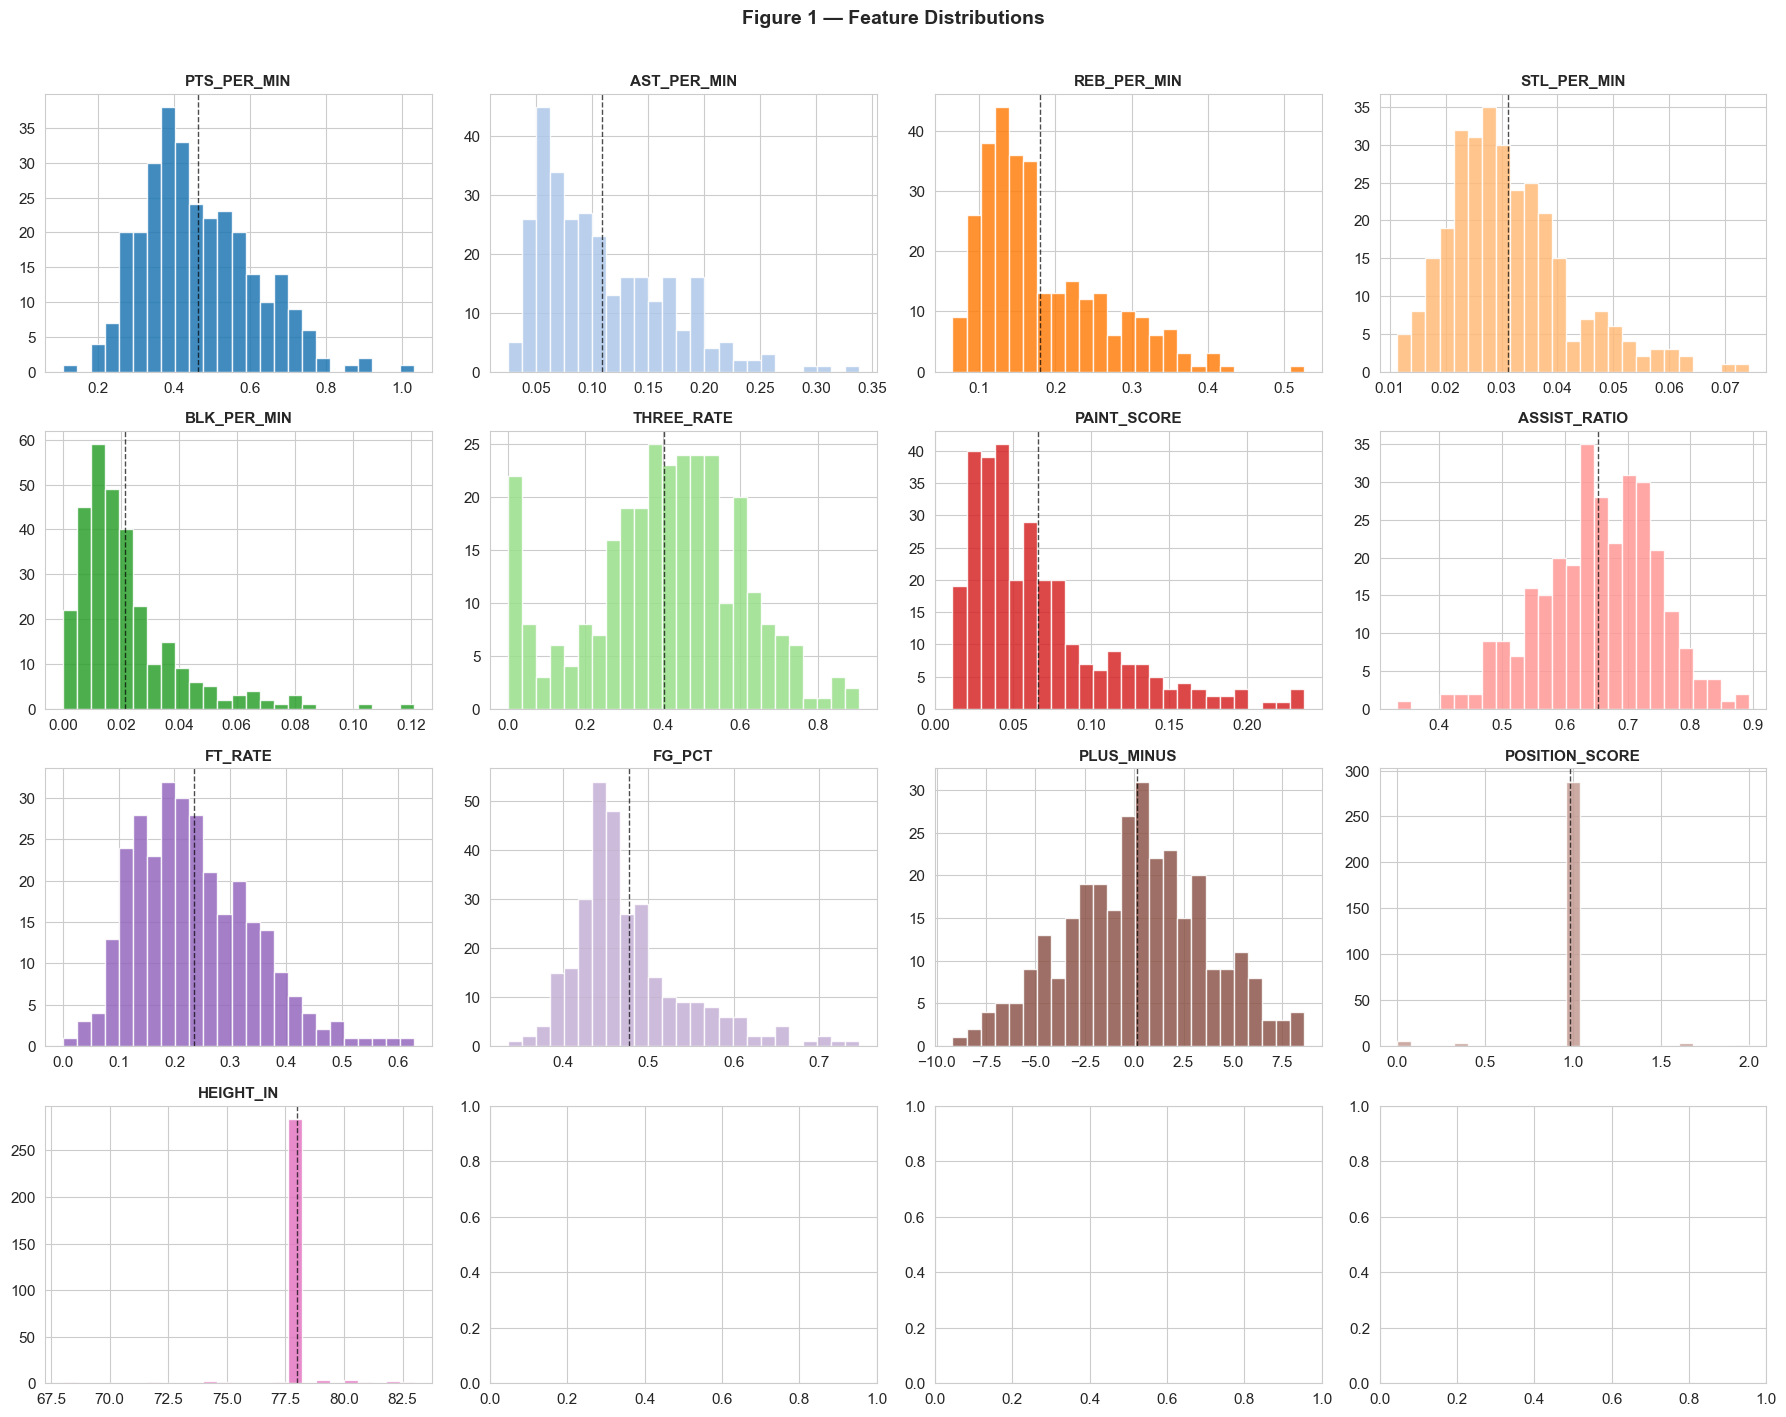

✓ Fig 1 saved


In [4]:
# Figure 1: Distributions
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
for i, col in enumerate(FEATURES):
    ax = axes.flatten()[i]
    ax.hist(df[col], bins=25, color=plt.cm.tab20.colors[i], edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(), color='black', linestyle='--', linewidth=1, alpha=0.7)
    ax.set_title(col, fontweight='bold', fontsize=11)
plt.suptitle('Figure 1 — Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/fig1_distributions.png', dpi=120, bbox_inches='tight')
plt.show(); print('✓ Fig 1 saved')

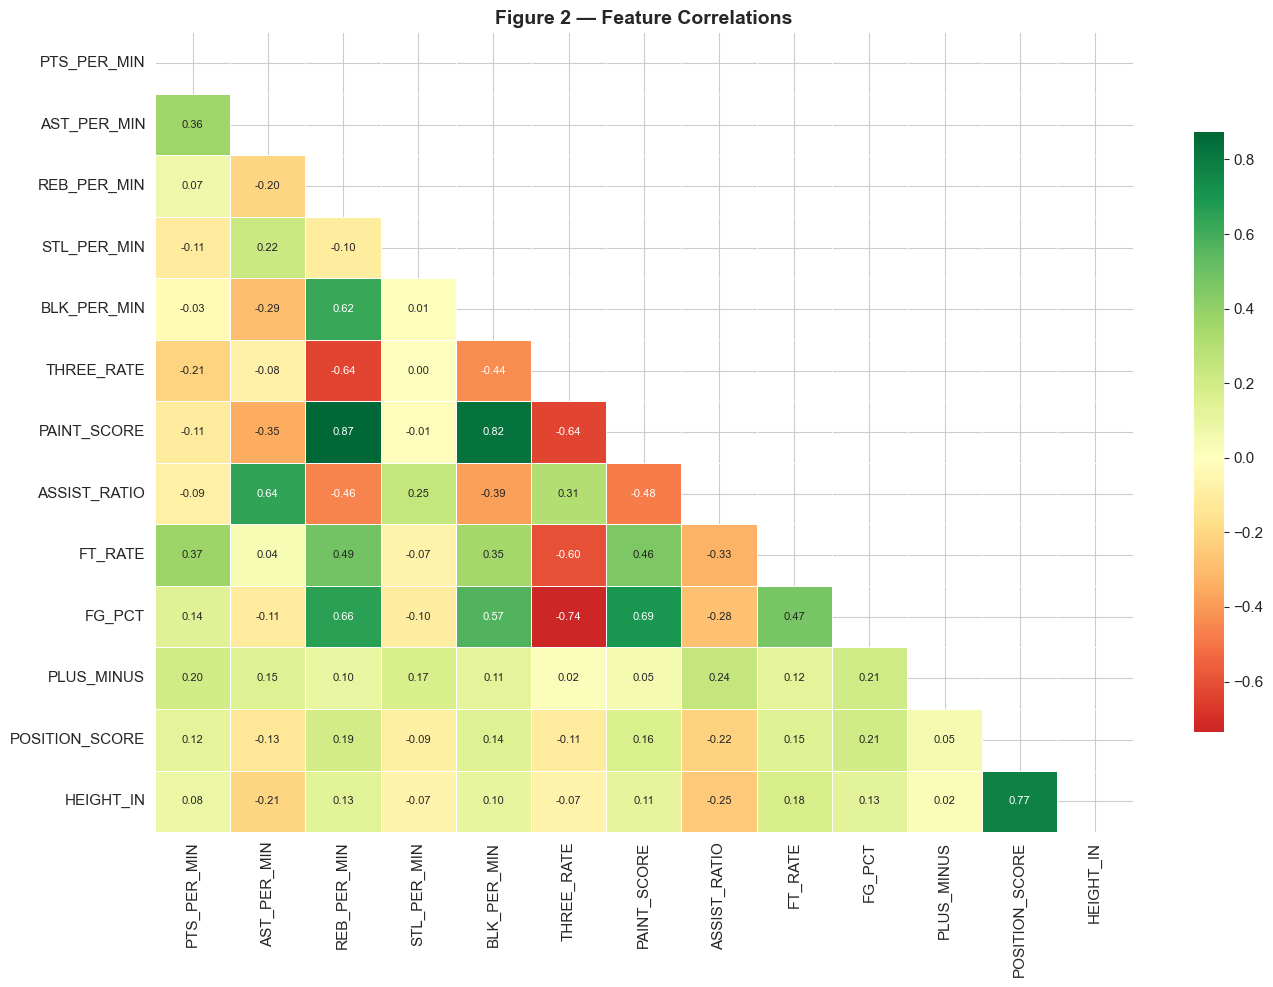

✓ Fig 2 saved


In [5]:
# Figure 2: Correlation heatmap
fig, ax = plt.subplots(figsize=(14, 10))
corr = df[FEATURES].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.75}, annot_kws={'size': 8})
ax.set_title('Figure 2 — Feature Correlations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/fig2_correlation.png', dpi=120, bbox_inches='tight')
plt.show(); print('✓ Fig 2 saved')

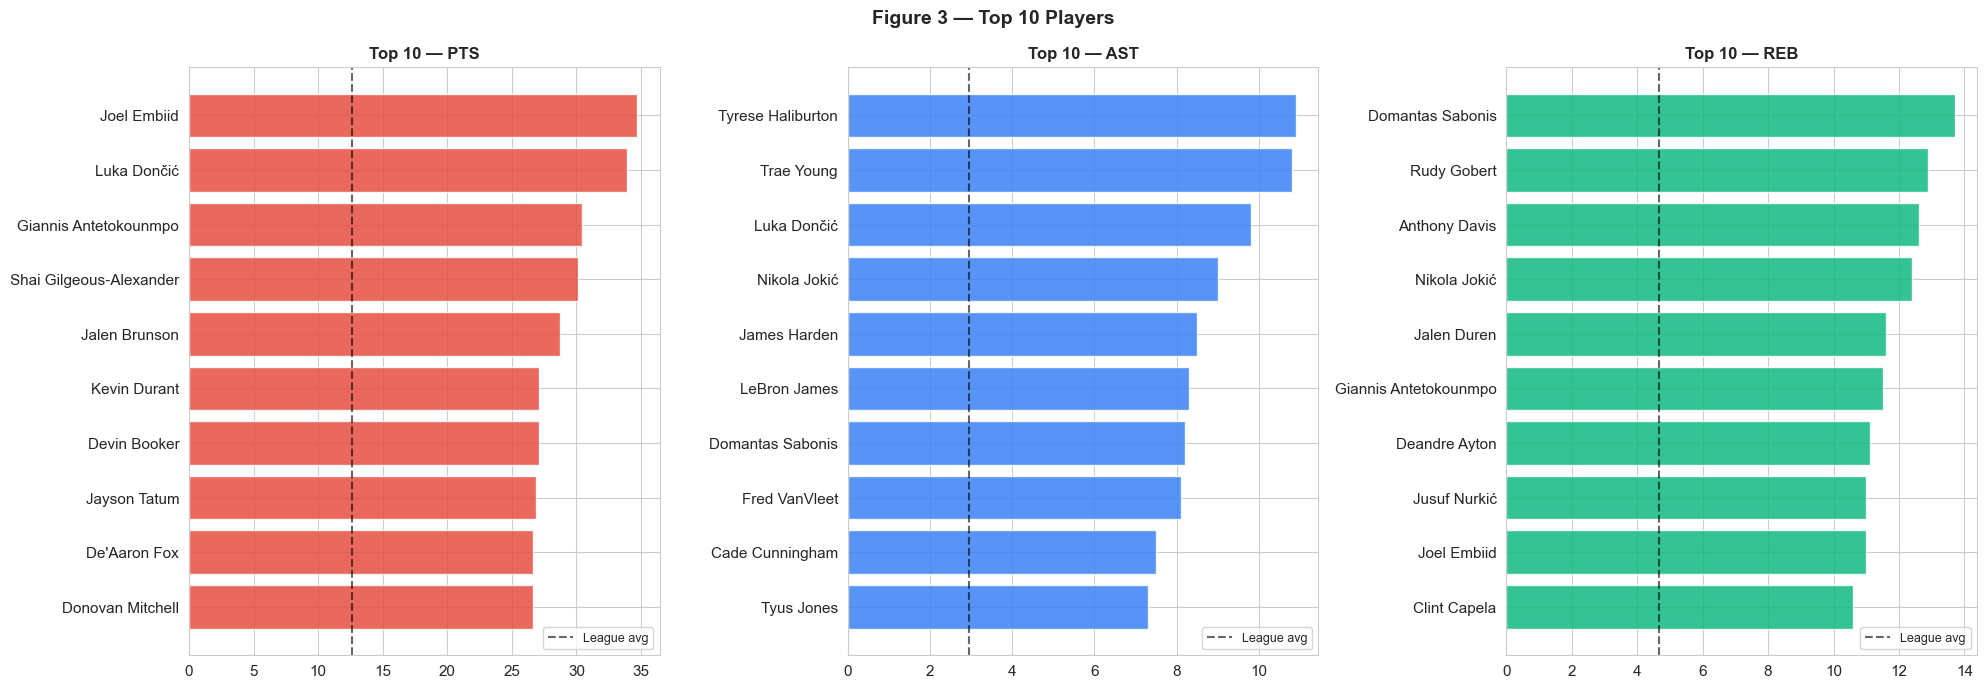

✓ Fig 3 saved


In [6]:
# Figure 3: Top 10 players
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
for ax, (col, color) in zip(axes, [('PTS', '#E84D3F'), ('AST', '#3B82F6'), ('REB', '#10B981')]):
    top = df.nlargest(10, col)[['PLAYER_NAME', col]].sort_values(col)
    ax.barh(top['PLAYER_NAME'], top[col], color=color, alpha=0.85, edgecolor='white')
    ax.axvline(df[col].mean(), color='black', linestyle='--', alpha=0.6, label='League avg')
    ax.set_title(f'Top 10 — {col}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
plt.suptitle('Figure 3 — Top 10 Players', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/fig3_top_players.png', dpi=120, bbox_inches='tight')
plt.show(); print('✓ Fig 3 saved')

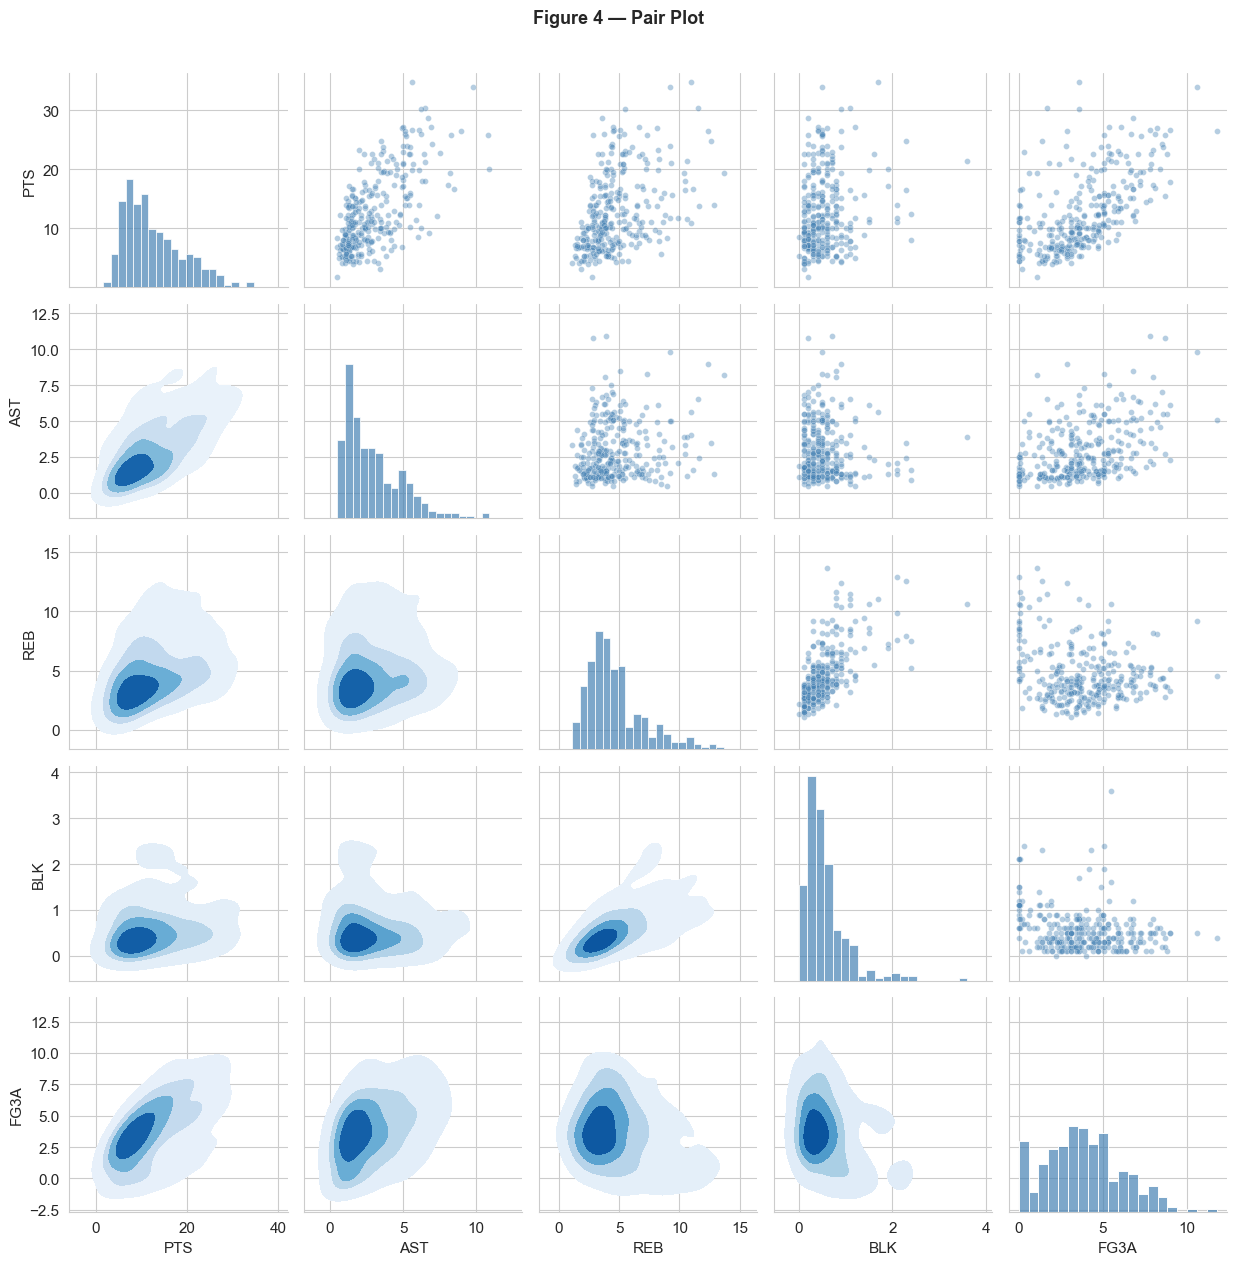

✓ Fig 4 saved


In [7]:
# Figure 4: Pair plot
pair_features = ['PTS', 'AST', 'REB', 'BLK', 'FG3A']
g = sns.PairGrid(df[pair_features])
g.map_upper(sns.scatterplot, alpha=0.4, s=18, color='steelblue')
g.map_lower(sns.kdeplot, fill=True, cmap='Blues', levels=5)
g.map_diag(sns.histplot, bins=20, color='steelblue', alpha=0.7)
g.figure.suptitle('Figure 4 — Pair Plot', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/fig4_pairplot.png', dpi=100, bbox_inches='tight')
plt.show(); print('✓ Fig 4 saved')

## 4. Clustering with K=6

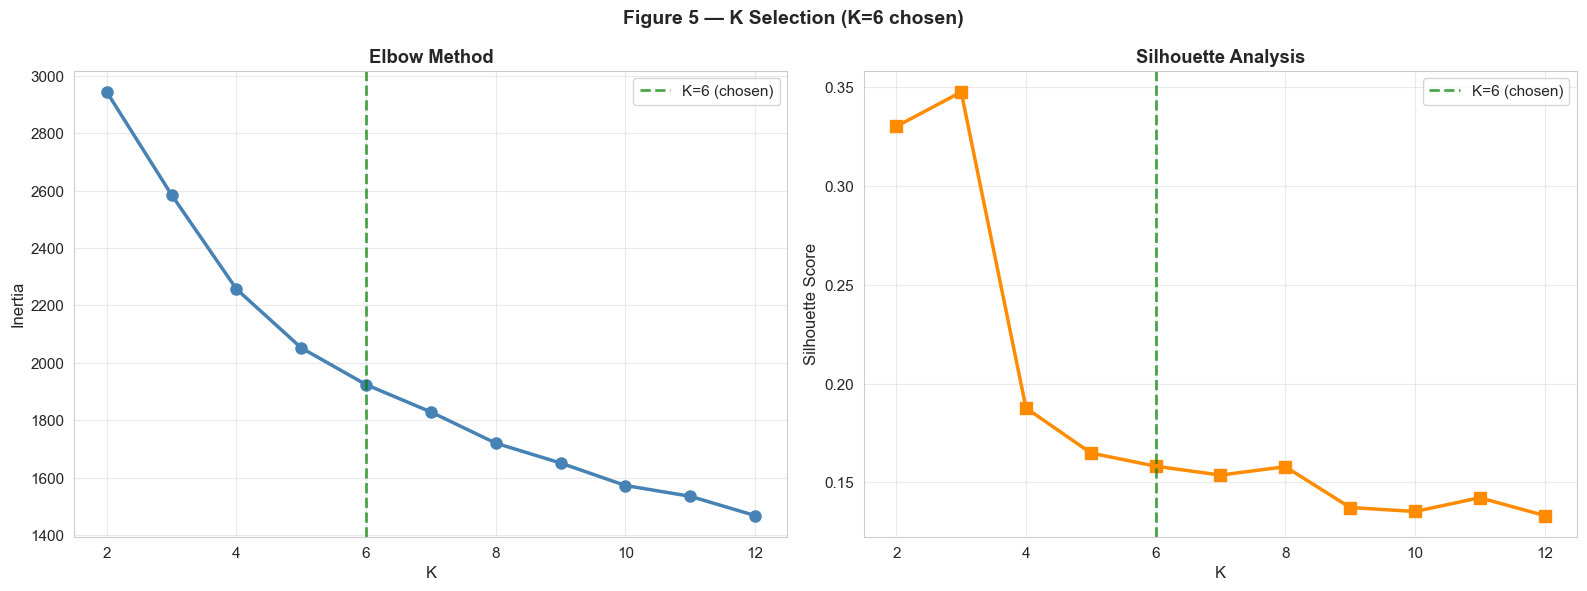

✓ Fig 5 saved


In [8]:
# Figure 5: Elbow + Silhouette
k_range = range(2, 13)
inertias, sil_scores = [], []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X, labels))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].plot(list(k_range), inertias, 'o-', color='steelblue', linewidth=2.5, markersize=8)
axes[0].axvline(6, color='green', linestyle='--', alpha=0.7, label='K=6 (chosen)', linewidth=2)
axes[0].set_xlabel('K', fontsize=12); axes[0].set_ylabel('Inertia', fontsize=12)
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.4)

axes[1].plot(list(k_range), sil_scores, 's-', color='darkorange', linewidth=2.5, markersize=8)
axes[1].axvline(6, color='green', linestyle='--', alpha=0.7, label='K=6 (chosen)', linewidth=2)
axes[1].set_xlabel('K', fontsize=12); axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Analysis', fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.4)

plt.suptitle('Figure 5 — K Selection (K=6 chosen)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/fig5_elbow_silhouette.png', dpi=120, bbox_inches='tight')
plt.show(); print('✓ Fig 5 saved')

In [9]:
# Fit K=6 KMeans
K = 6
kmeans = KMeans(n_clusters=K, random_state=42, n_init=20)
df['Cluster'] = kmeans.fit_predict(X)

centers = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(centers, columns=FEATURES)

print(f'K={K} clustering complete | Inertia: {kmeans.inertia_:.2f}')
print(f'\nCluster sizes:')
print(df['Cluster'].value_counts().sort_index())

K=6 clustering complete | Inertia: 1923.55

Cluster sizes:
Cluster
0    51
1    75
2    43
3    38
4     6
5    88
Name: count, dtype: int64


In [10]:
# Auction-based archetype labeling -- guarantees every cluster a unique, meaningful label
ARCHETYPES = {
    'Elite Scorer':       {'primary': 'PTS_PER_MIN',  'secondary': ['FT_RATE', 'ASSIST_RATIO']},
    'Playmaker':          {'primary': 'AST_PER_MIN',   'secondary': ['ASSIST_RATIO', 'PTS_PER_MIN']},
    '3PT Specialist':     {'primary': 'THREE_RATE',    'secondary': ['AST_PER_MIN', 'STL_PER_MIN']},
    'Rim Protector':      {'primary': 'BLK_PER_MIN',   'secondary': ['PAINT_SCORE', 'REB_PER_MIN']},
    'Rebounding Big':     {'primary': 'REB_PER_MIN',   'secondary': ['PAINT_SCORE', 'BLK_PER_MIN']},
    'Perimeter Defender': {'primary': 'STL_PER_MIN',   'secondary': ['THREE_RATE', 'AST_PER_MIN']},
}

def auto_label(centers_df, K):
    archetypes = list(ARCHETYPES.keys())
    n_arch = len(archetypes)
    scores = np.zeros((K, n_arch))
    for j, arch in enumerate(archetypes):
        defn = ARCHETYPES[arch]
        if defn['primary'] in centers_df.columns:
            scores[:, j] += centers_df[defn['primary']].values * 2.0
        for sec in defn['secondary']:
            if sec in centers_df.columns:
                scores[:, j] += centers_df[sec].values * 0.5
    labels = {}
    score_mat = scores.copy()
    for _ in range(min(K, n_arch)):
        flat_idx = int(np.argmax(score_mat))
        c_idx, a_idx = divmod(flat_idx, n_arch)
        labels[c_idx] = archetypes[a_idx]
        score_mat[c_idx, :] = -np.inf
        score_mat[:, a_idx] = -np.inf
    for i in range(K):
        if i not in labels:
            labels[i] = 'Role Players'
    return labels

ARCHETYPE_MAP = auto_label(centers_df, K)
df['Archetype'] = df['Cluster'].map(ARCHETYPE_MAP)

for c in range(K):
    n = (df['Cluster'] == c).sum()
    print(f'C{c}: {ARCHETYPE_MAP[c]:20s} -- {n:3d} players')

C0: Playmaker            --  51 players
C1: 3PT Specialist       --  75 players
C2: Rebounding Big       --  43 players
C3: Elite Scorer         --  38 players
C4: Perimeter Defender   --   6 players
C5: Rim Protector        --  88 players


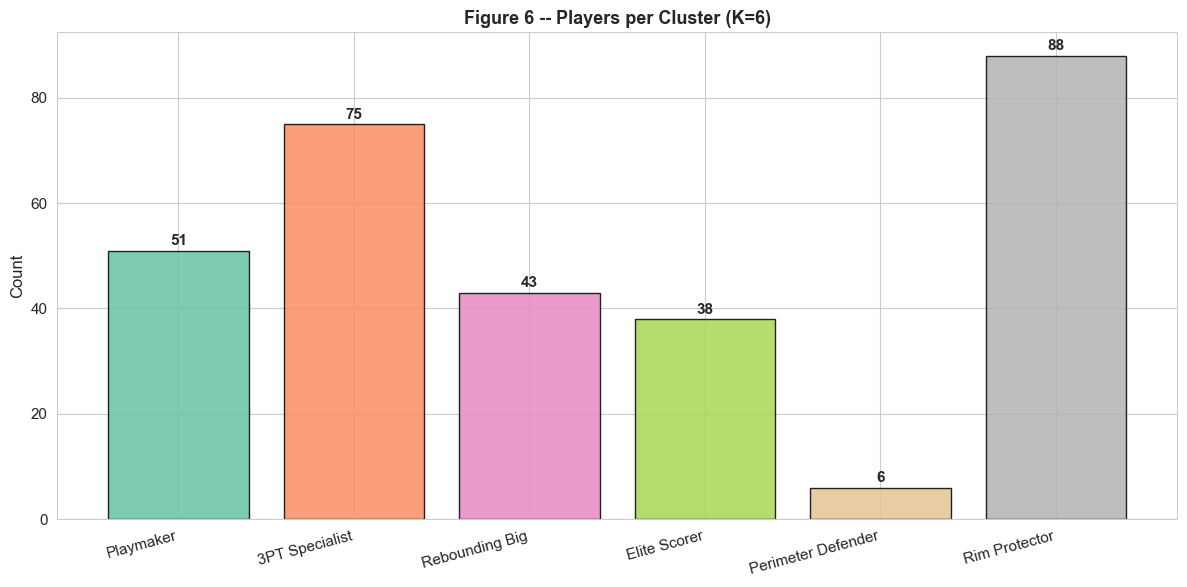

Fig 6 saved


In [11]:
# Figure 6: Cluster sizes
sizes = df['Cluster'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(12, 6))
palette = [plt.cm.Set2(i / max(K - 1, 1)) for i in range(K)]
labels_list = [ARCHETYPE_MAP[c] for c in range(K)]
bars = ax.bar(labels_list, [sizes[c] for c in range(K)], color=palette, edgecolor='black', alpha=0.85)
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 1, f'{int(h)}', ha='center', fontweight='bold')
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Figure 6 -- Players per Cluster (K=6)', fontsize=13, fontweight='bold')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('../data/fig6_cluster_sizes.png', dpi=120, bbox_inches='tight')
plt.show()
print('Fig 6 saved')

## 5. Dimensionality Reduction

PC1: 35.0%
PC1+PC2: 50.3%


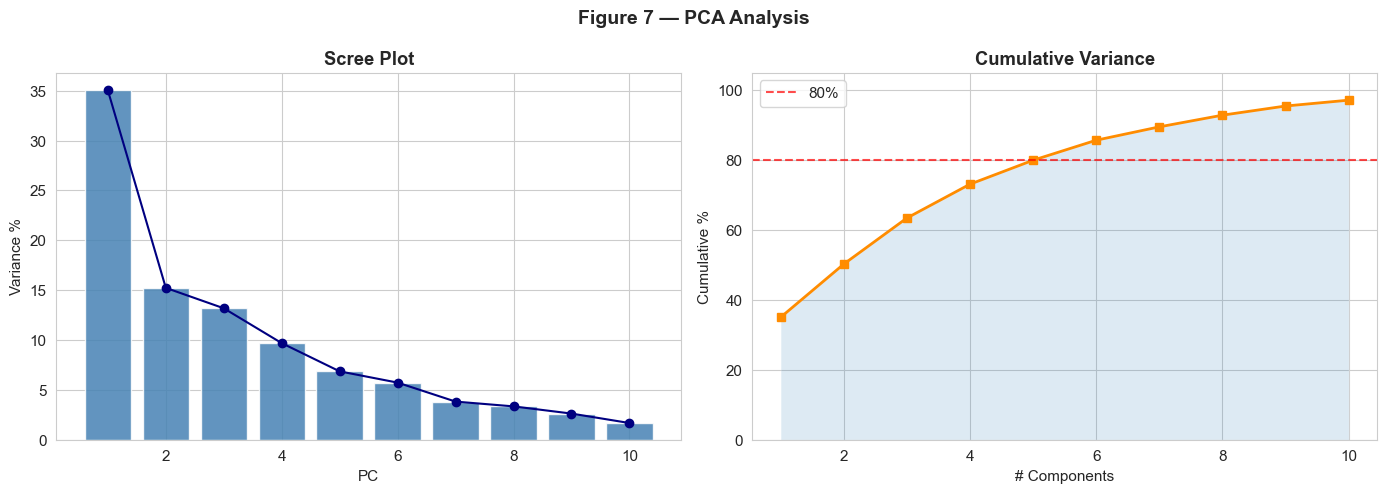

✓ Fig 7 saved


In [12]:
# PCA
pca = PCA(n_components=min(10, len(FEATURES)), random_state=42)
X_pca_full = pca.fit_transform(X)
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

print(f'PC1: {explained[0]*100:.1f}%')
print(f'PC1+PC2: {cumulative[1]*100:.1f}%')

# Figure 7: PCA variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(range(1, len(explained)+1), explained*100, color='steelblue', alpha=0.85)
axes[0].plot(range(1, len(explained)+1), explained*100, 'o-', color='navy', linewidth=1.5)
axes[0].set_xlabel('PC'); axes[0].set_ylabel('Variance %')
axes[0].set_title('Scree Plot', fontweight='bold')

axes[1].plot(range(1, len(explained)+1), cumulative*100, 's-', color='darkorange', linewidth=2)
axes[1].axhline(80, color='red', linestyle='--', alpha=0.7, label='80%')
axes[1].fill_between(range(1, len(explained)+1), cumulative*100, alpha=0.15)
axes[1].set_xlabel('# Components'); axes[1].set_ylabel('Cumulative %')
axes[1].set_title('Cumulative Variance', fontweight='bold')
axes[1].legend(); axes[1].set_ylim(0, 105)

plt.suptitle('Figure 7 — PCA Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/fig7_pca_variance.png', dpi=120, bbox_inches='tight')
plt.show(); print('✓ Fig 7 saved')

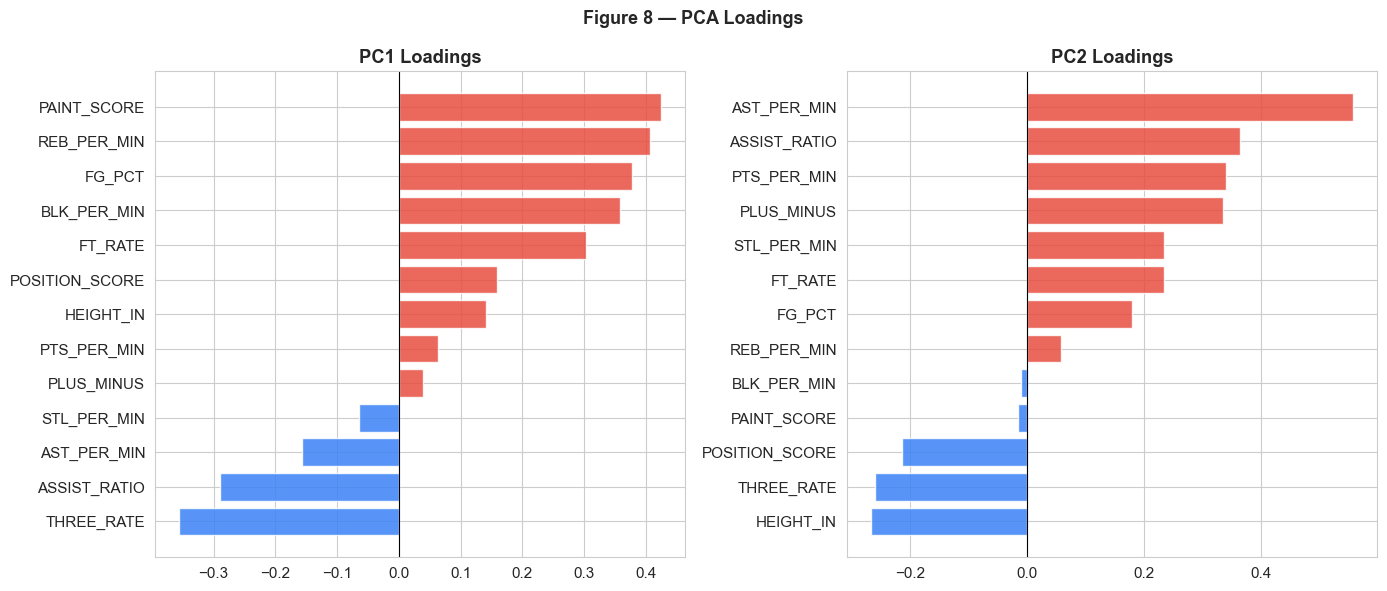

✓ Fig 8 saved


In [13]:
# Figure 8: PCA loadings
loadings = pd.DataFrame(pca.components_[:2].T, index=FEATURES, columns=['PC1', 'PC2'])
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, pc in zip(axes, ['PC1', 'PC2']):
    s = loadings[pc].sort_values()
    colors = ['#E84D3F' if v > 0 else '#3B82F6' for v in s]
    ax.barh(s.index, s.values, color=colors, alpha=0.85)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{pc} Loadings', fontweight='bold')
plt.suptitle('Figure 8 — PCA Loadings', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/fig8_pca_loadings.png', dpi=120, bbox_inches='tight')
plt.show(); print('✓ Fig 8 saved')

In [14]:
# UMAP
if UMAP_AVAILABLE:
    print('Running UMAP...')
    reducer = umap_module.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42, verbose=False)
    X_umap = reducer.fit_transform(X)
else:
    print('UMAP not available — using PCA fallback')
    X_umap = X_pca_full[:, :2]

df['PC1'] = X_pca_full[:, 0]
df['PC2'] = X_pca_full[:, 1]
df['UMAP1'] = X_umap[:, 0]
df['UMAP2'] = X_umap[:, 1]
print('✓ Dimensionality reduction complete')

Running UMAP...


✓ Dimensionality reduction complete


## 6. Interactive Visualizations

In [15]:
# Figure 9: PCA scatter (Plotly)
fig = px.scatter(df, x='PC1', y='PC2', color='Archetype', hover_name='PLAYER_NAME',
    hover_data={'TEAM_ABBREVIATION': True, 'PTS': ':.1f', 'AST': ':.1f', 'REB': ':.1f', 'PC1': False, 'PC2': False},
    title=f'Figure 9 -- PCA Projection (K={K})',
    color_discrete_sequence=px.colors.qualitative.Set2, width=980, height=620)
fig.update_traces(marker=dict(size=8, opacity=0.82, line=dict(width=0.5, color='white')))
fig.update_layout(xaxis_title=f'PC1 ({explained[0]*100:.1f}%)', yaxis_title=f'PC2 ({explained[1]*100:.1f}%)')
fig.write_html('../data/fig9_pca_scatter.html')
print('Fig 9 saved to ../data/fig9_pca_scatter.html')

Fig 9 saved to ../data/fig9_pca_scatter.html


In [16]:
# Figure 10: UMAP scatter (Plotly)
fig = px.scatter(df, x='UMAP1', y='UMAP2', color='Archetype', hover_name='PLAYER_NAME',
    hover_data={'TEAM_ABBREVIATION': True, 'PTS': ':.1f', 'AST': ':.1f', 'REB': ':.1f', 'UMAP1': False, 'UMAP2': False},
    title=f'Figure 10 -- UMAP Projection (K={K})',
    color_discrete_sequence=px.colors.qualitative.Set2, width=980, height=620)
fig.update_traces(marker=dict(size=9, opacity=0.82, line=dict(width=0.5, color='white')))
fig.write_html('../data/fig10_umap_scatter.html')
print('Fig 10 saved to ../data/fig10_umap_scatter.html')

Fig 10 saved to ../data/fig10_umap_scatter.html

In [17]:
# Figure 11: Radar chart (Plotly)
RADAR_FEATURES = ['PTS', 'AST', 'REB', 'STL', 'BLK', 'FG3A', 'TOV']
cluster_means = df.groupby('Cluster')[RADAR_FEATURES].mean()
cmin = cluster_means.min(); cmax = cluster_means.max()
cluster_norm = (cluster_means - cmin) / (cmax - cmin + 1e-9)

palette_hex = [f'#{int(r*255):02x}{int(g*255):02x}{int(b*255):02x}'
               for r,g,b,_ in [plt.cm.Set2(i/max(K-1,1)) for i in range(K)]]
theta = RADAR_FEATURES + [RADAR_FEATURES[0]]
fig = go.Figure()
for i in range(K):
    vals = cluster_norm.loc[i, RADAR_FEATURES].tolist() + [cluster_norm.loc[i, RADAR_FEATURES[0]]]
    fig.add_trace(go.Scatterpolar(r=vals, theta=theta, fill='toself',
        name=f'C{i}: {ARCHETYPE_MAP[i]}', line_color=palette_hex[i], opacity=0.6))
fig.update_layout(polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
    title='Figure 11 -- Cluster Archetypes (Normalized Profiles)', width=800, height=700)
fig.write_html('../data/fig11_radar.html')
print('Fig 11 saved to ../data/fig11_radar.html')

Fig 11 saved to ../data/fig11_radar.html


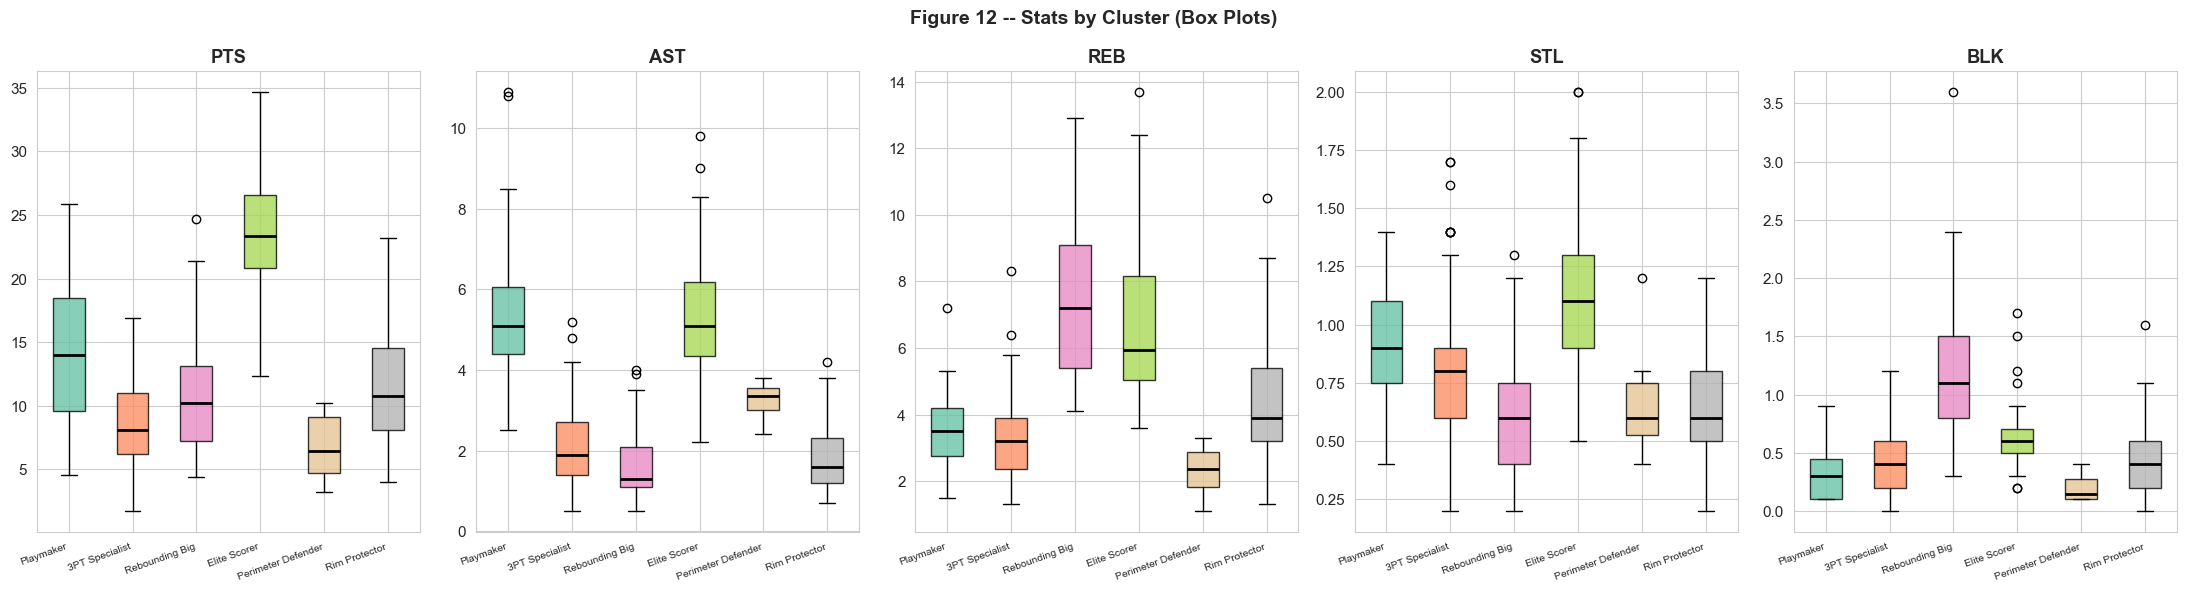

Fig 12 saved


In [18]:
# Figure 12: Box plots
KEY_STATS = ['PTS', 'AST', 'REB', 'STL', 'BLK']
pal = [plt.cm.Set2(i / max(K - 1, 1)) for i in range(K)]
fig, axes = plt.subplots(1, 5, figsize=(22, 6))
for ax, stat in zip(axes, KEY_STATS):
    data = [df[df['Cluster'] == c][stat].values for c in range(K)]
    bp = ax.boxplot(data, patch_artist=True, medianprops=dict(color='black', linewidth=2))
    for patch, c in zip(bp['boxes'], range(K)):
        patch.set_facecolor(pal[c]); patch.set_alpha(0.78)
    ax.set_xticklabels([ARCHETYPE_MAP[c] for c in range(K)], fontsize=7.5, rotation=20, ha='right')
    ax.set_title(stat, fontweight='bold')
plt.suptitle('Figure 12 -- Stats by Cluster (Box Plots)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/fig12_boxplots.png', dpi=120, bbox_inches='tight')
plt.show()
print('Fig 12 saved')

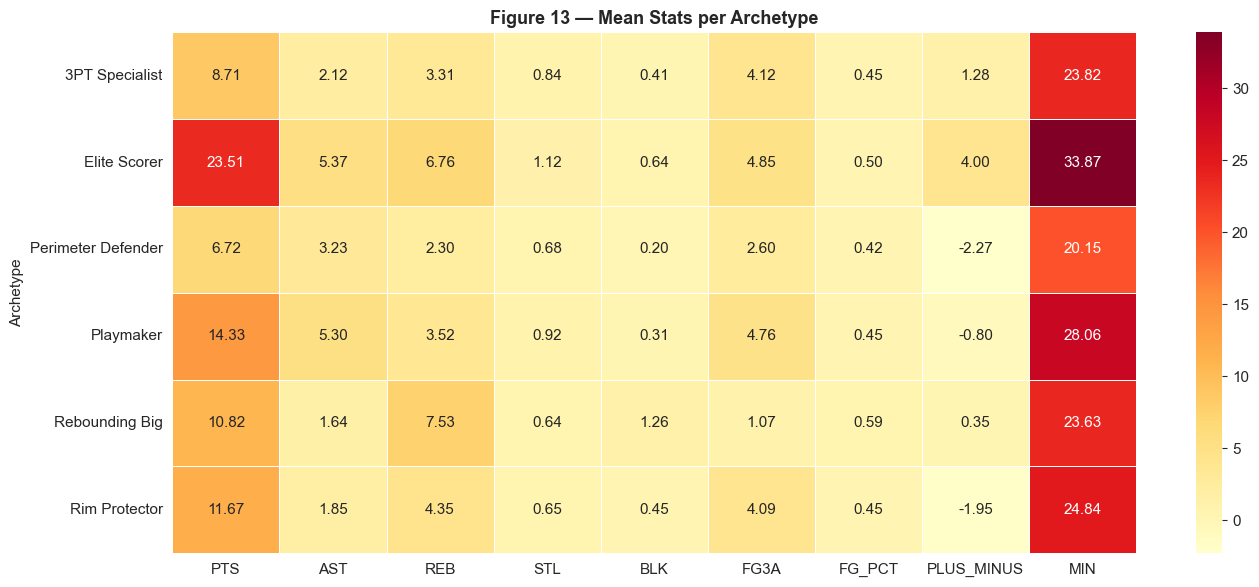

✓ Fig 13 saved


In [19]:
# Figure 13: Heatmap
profile_features = ['PTS', 'AST', 'REB', 'STL', 'BLK', 'FG3A', 'FG_PCT', 'PLUS_MINUS', 'MIN']
cluster_profile = df.groupby('Archetype')[profile_features].mean().round(2)
fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(cluster_profile, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('Figure 13 — Mean Stats per Archetype', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/fig13_cluster_heatmap.png', dpi=120, bbox_inches='tight')
plt.show(); print('✓ Fig 13 saved')

In [20]:
# Top 5 per cluster
print('\n' + '='*80)
print('TOP 5 REPRESENTATIVE PLAYERS PER CLUSTER')
print('='*80)
for c in range(K):
    subset = df[df['Cluster'] == c].nlargest(5, 'MIN')
    total = (df['Cluster'] == c).sum()
    print(f'\nCluster {c}: {ARCHETYPE_MAP[c]} ({total} players)')
    print(subset[['PLAYER_NAME', 'TEAM_ABBREVIATION', 'PTS', 'AST', 'REB', 'MIN']].to_string(index=False))


TOP 5 REPRESENTATIVE PLAYERS PER CLUSTER

Cluster 0: Playmaker (51 players)
    PLAYER_NAME TEAM_ABBREVIATION  PTS  AST  REB  MIN
   Tyrese Maxey               PHI 25.9  6.2  3.7 37.5
  Fred VanVleet               HOU 17.4  8.1  3.8 36.8
     Coby White               CHI 19.1  5.1  4.5 36.5
     Trae Young               ATL 25.7 10.8  2.8 36.0
Dejounte Murray               ATL 22.5  6.4  5.3 35.7

Cluster 1: 3PT Specialist (75 players)
  PLAYER_NAME TEAM_ABBREVIATION  PTS  AST  REB  MIN
   OG Anunoby               NYK 14.7  2.1  4.2 34.0
Keegan Murray               SAC 15.2  1.7  5.5 33.6
Grayson Allen               PHX 13.5  3.0  3.9 33.5
    Josh Hart               NYK  9.4  4.1  8.3 33.4
 Jrue Holiday               BOS 12.5  4.8  5.4 32.8

Cluster 2: Rebounding Big (43 players)
  PLAYER_NAME TEAM_ABBREVIATION  PTS  AST  REB  MIN
Anthony Davis               LAL 24.7  3.5 12.6 35.5
  Rudy Gobert               MIN 14.0  1.3 12.9 34.1
Deandre Ayton               POR 16.7  1.6 11.1 32.4

---

## Summary

✓ **Analysis Complete**
- **Data:** 283 players (filtered: ≥30 GP, ≥15 MIN/G) from 540 raw
- **Features:** 16 statistics
- **Clusters:** 6 distinct archetypes
- **Visualizations:** 13 figures (distributions, correlations, clustering, projections)
- **Outputs:** All figures saved to `../data/`